In [ ]:
from langgraph.graph import StateGraph, START, END 
from langchain_google_genai import ChatGoogleGenerativeAI 
from typing import TypedDict , Annotated
from dotenv import load_dotenv 
from pydantic import BaseModel, Field
import operator
load_dotenv()

In [ ]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [ ]:
class EvaluationSchema(BaseModel):
  feedback: str = Field(description="Feedback on the essay")
  score: int = Field(description="Score out of 10", ge=0, le=10)


In [ ]:
structured_model = model.with_structured_output(EvaluationSchema)

In [ ]:
essay = """In the heart of the bustling city, there was a small park that served as a sanctuary for its residents. The park was filled with lush greenery, vibrant flowers, and towering trees that provided shade on sunny days. People from all walks of life would gather there to relax, exercise, and connect with nature. Children would play on the swings and slides, while adults would take leisurely strolls along the winding paths. The park was not just a place for recreation; it was a symbol of community and togetherness in the midst of urban chaos.
Also, the park hosted various events and activities throughout the year, from outdoor concerts to farmers' markets. It was a place where friendships were forged, memories were made, and the stresses of city life melted away. The park was a testament to the importance of green spaces in urban environments and the positive impact they have on mental and physical well-being.Whereas the park provided a peaceful escape for many, it also faced challenges such as maintenance issues and occasional vandalism. However, the community's dedication to preserving this green oasis ensured that it remained a cherished part of the city for generations to come.
"""

In [ ]:
class UPSCEssayEvaluationSchema(TypedDict):
  essay: str
  language_feedback: str
  content_feedback: str
  clarity_feedback: str
  overall_feedback: str
  individual_scores: Annotated[list[int], operator.add]
  average_score: float

In [ ]:
def evaluateLanguage(state: UPSCEssayEvaluationSchema) -> UPSCEssayEvaluationSchema:
  prompt = f"Evaluate the language used in the following essay and provide feedback and rate it out of 10:\n\n{state['essay']}"
  language_feedback = structured_model.invoke(prompt)
  return {'language_feedback': language_feedback, 'individual_scores': [language_feedback.score]}

In [ ]:
def evaluateContent(state: UPSCEssayEvaluationSchema) -> UPSCEssayEvaluationSchema:
  prompt = f"Evaluate the content of the following essay and provide feedback and rate it out of 10:\n\n{state['essay']}"
  content_feedback = structured_model.invoke(prompt)
  return {'content_feedback': content_feedback, 'individual_scores': [content_feedback.score]}

In [ ]:
def evaluateClarity(state: UPSCEssayEvaluationSchema) -> UPSCEssayEvaluationSchema:
  prompt = f"Evaluate the clarity of the following essay and provide feedback and rate it out of 10:\n\n{state['essay']}"
  clarity_feedback = structured_model.invoke(prompt)
  return {'clarity_feedback': clarity_feedback, 'individual_scores': [clarity_feedback.score]}

In [ ]:
def aggregateFeedback(state: UPSCEssayEvaluationSchema) -> UPSCEssayEvaluationSchema:
  prompt = f"Aggregate the following feedback and scores for the essay and provide overall feedback and an average score:\n\nLanguage Feedback: {state['language_feedback']}\nContent Feedback: {state['content_feedback']}\nClarity Feedback: {state['clarity_feedback']}\nIndividual Scores: {state['individual_scores']}"
  overall_feedback = structured_model.invoke(prompt).content
  average_score = sum(state['individual_scores']) / len(state['individual_scores'])
  return {'overall_feedback': overall_feedback, 'average_score': average_score}

In [ ]:
graph = StateGraph(UPSCEssayEvaluationSchema)

graph.add_node('language_feedback', evaluateLanguage)
graph.add_node('content_feedback', evaluateContent)
graph.add_node('clarity_feedback', evaluateClarity)
graph.add_node('overall feedback', aggregateFeedback)

graph.add_edge(START, 'language_feedback')
graph.add_edge(START, 'content_feedback')
graph.add_edge(START, 'clarity_feedback')
graph.add_edge('language_feedback', 'overall feedback')
graph.add_edge('content_feedback', 'overall feedback')
graph.add_edge('clarity_feedback', 'overall feedback')
graph.add_edge('overall feedback', END)

workflow = graph.compile()

In [ ]:
initial_state = {
  'essay': essay
}
result = workflow.invoke(initial_state)

print(result)

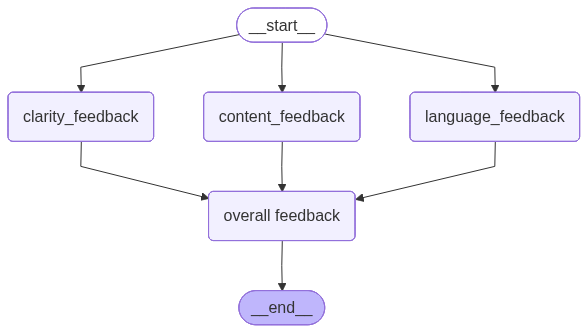

In [25]:
workflow